In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Retail_Sales_Dataset_.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [8]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [9]:
(df["Quantity"] * df["Price per Unit"] == df["Total Amount"]).sum()

np.int64(1000)

In [10]:
len(df)

1000

In [11]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [12]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [13]:
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [14]:
df["Total Amount"].sum()

np.int64(456000)

In [15]:
df["Total Amount"].mean()

np.float64(456.0)

In [16]:
df["Quantity"].sum()

np.int64(2514)

In [17]:
(df.groupby("Product Category")["Total Amount"].sum() 
 / df["Total Amount"].sum()) * 100

Product Category
Beauty         31.472588
Clothing       34.118421
Electronics    34.408991
Name: Total Amount, dtype: float64

In [18]:
df["Month"] = df["Date"].dt.month

In [19]:
df[["Date","Month"]].head()

,Date,Month
0,2023-11-24,11
1,2023-02-27,2
2,2023-01-13,1
3,2023-05-21,5
4,2023-05-06,5


In [20]:
df.groupby("Month")["Total Amount"].sum().sort_index()

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

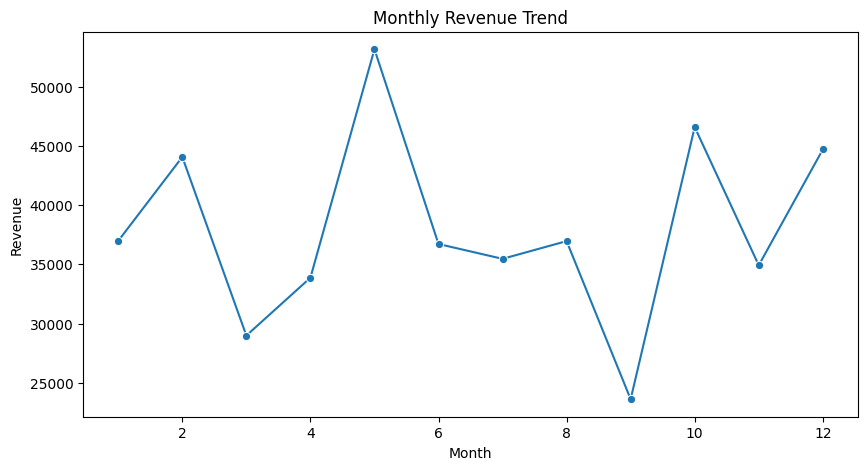

In [21]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [22]:
df.groupby("Gender")["Total Amount"].mean()

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

In [23]:
bins = [17, 24, 34, 44, 54, 64]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [24]:
df[["Age","Age Group"]].head()

,Age,Age Group
0,34,25-34
1,26,25-34
2,50,45-54
3,37,35-44
4,30,25-34


In [25]:
df.groupby("Age Group")["Total Amount"].mean().sort_values(ascending=False)

Age Group
18-24    501.006711
25-34    478.275862
35-44    467.801932
45-54    432.155556
55-64    417.546296
Name: Total Amount, dtype: float64

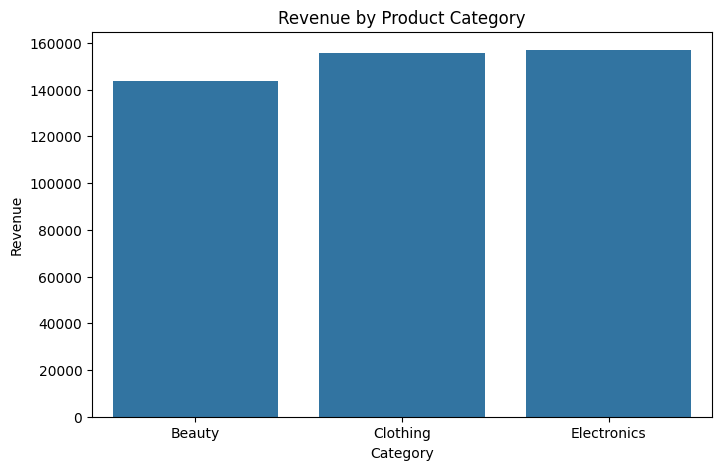

In [26]:
cat_rev = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=cat_rev.index, y=cat_rev.values)
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

# Retail Sales Performance Monitoring System

## Key Business Insights

1. The store generated a total annual revenue of ₹4,56,000 across 1000 transactions.

2. The average order value (AOV) is ₹456 per transaction.

3. Electronics is the highest revenue-generating category, while Clothing drives customer footfall.

4. The customer base is evenly distributed between male and female shoppers, with no significant difference in spending behavior.

5. Customers aged 18–24 generate the highest average bill value, making them the most valuable customer segment.

6. Sales show strong seasonality, with peak revenue occurring in May and secondary peaks during October and December, while September is the weakest month.

7. Beauty category contributes the least revenue and may benefit from promotional strategies.